# CSE-CIC-IDS2018 — CTGAN Data Preparation & Augmentation

Optimized to run **locally** (VS Code / Jupyter) — no Google Colab dependencies.

**Pipeline covered here:**
1. Configuration & setup
2. Load `ml_dataset.parquet` (output of notebook 1) and final cleanup
3. Label encoding + stratified train/test split
4. Feature selection via mutual information
5. CTGAN-based augmentation of minority attack classes
6. Merge synthetic + real data into a final balanced training set

> Requires the `ctgan` package: `pip install ctgan`

## 1. Configuration & Setup

In [24]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 100)

In [25]:
PROJECT_PATH = Path(r"M:\IDS\c_filesnew")

PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
RESULTS_PATH        = PROJECT_PATH / "Results"
CTGAN_PATH          = PROJECT_PATH / "CTGAN"
CTGAN_MODELS_PATH   = CTGAN_PATH / "Models"
CTGAN_SYNTHETIC_PATH = CTGAN_PATH / "Synthetic"

for p in [PROCESSED_DATA_PATH, RESULTS_PATH, CTGAN_MODELS_PATH, CTGAN_SYNTHETIC_PATH]:
    p.mkdir(parents=True, exist_ok=True)

ML_DATA = PROCESSED_DATA_PATH / "ml_dataset.parquet"
print("Loading:", ML_DATA)

Loading: M:\IDS\c_filesnew\Processed_Data\ml_dataset.parquet


## 2. Load & Final Cleanup

In [26]:
df = pd.read_parquet(ML_DATA)
print("Shape:", df.shape)
df.head()

Shape: (1002490, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,21/02/2018 02:19:52,8174,2,0,0,0,0,0,...,20,0,0,0,0,0.0,0.0,0,0,DDOS attack-HOIC
1,80,6,21/02/2018 02:18:34,2331,2,0,0,0,0,0,...,20,0,0,0,0,0.0,0.0,0,0,DDOS attack-HOIC
2,80,6,21/02/2018 02:11:40,14227,3,4,324,935,324,0,...,20,0,0,0,0,0.0,0.0,0,0,DDOS attack-HOIC
3,80,6,21/02/2018 02:21:20,7020,2,0,0,0,0,0,...,20,0,0,0,0,0.0,0.0,0,0,DDOS attack-HOIC
4,80,6,21/02/2018 02:30:20,12936,2,0,0,0,0,0,...,20,0,0,0,0,0.0,0.0,0,0,DDOS attack-HOIC


In [27]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Missing values :", df.isnull().sum().sum())
print("Infinite values:", int(np.isinf(df[numeric_cols]).sum().sum()))
print("Duplicate rows :", df.duplicated().sum())

Missing values : 0
Infinite values: 0
Duplicate rows : 0


In [28]:
# Replace remaining infinities, median-impute, drop Timestamp (not a model feature)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

if "Timestamp" in df.columns:
    df.drop(columns=["Timestamp"], inplace=True)

print("Missing after cleanup :", df.isnull().sum().sum())
print("Shape                 :", df.shape)

Missing after cleanup : 0
Shape                 : (1002490, 79)


## 3. Label Encoding + Train/Test Split

In [29]:
encoder = LabelEncoder()
df["Label"] = encoder.fit_transform(df["Label"])

label_mapping = pd.DataFrame({
    "Class": encoder.classes_,
    "Encoded": encoder.transform(encoder.classes_),
})
label_mapping.to_csv(PROCESSED_DATA_PATH / "label_mapping.csv", index=False)

label_to_id = dict(zip(label_mapping["Class"], label_mapping["Encoded"]))
id_to_label = dict(zip(label_mapping["Encoded"], label_mapping["Class"]))

label_mapping

,Class,Encoded
0,Benign,0
1,Bot,1
2,Brute Force -Web,2
3,Brute Force -XSS,3
4,DDOS attack-HOIC,4
5,DDOS attack-LOIC-UDP,5
6,DDoS attacks-LOIC-HTTP,6
7,DoS attacks-GoldenEye,7
8,DoS attacks-Hulk,8
9,DoS attacks-SlowHTTPTest,9


In [30]:
X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy(); train_df["Label"] = y_train.values
test_df = X_test.copy();   test_df["Label"] = y_test.values

train_df.to_parquet(PROCESSED_DATA_PATH / "train.parquet", index=False)
test_df.to_parquet(PROCESSED_DATA_PATH / "test.parquet", index=False)

print("Train:", train_df.shape, " Test:", test_df.shape)

Train: (801992, 79)  Test: (200498, 79)


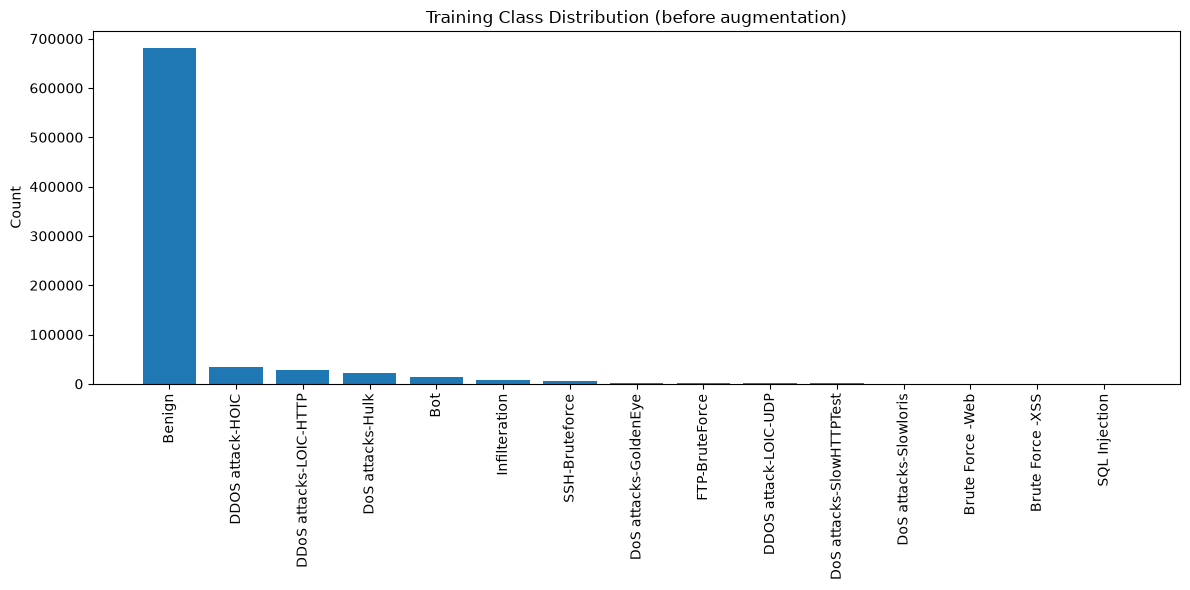

,Class,Count
0,Benign,680805
1,DDOS attack-HOIC,33844
2,DDoS attacks-LOIC-HTTP,29171
3,DoS attacks-Hulk,22017
4,Bot,14293
5,Infilteration,8197
6,SSH-Bruteforce,5940
7,DoS attacks-GoldenEye,2099
8,FTP-BruteForce,1992
9,DDOS attack-LOIC-UDP,1384


In [31]:
dist = (
    train_df["Label"].map(id_to_label).value_counts().reset_index()
)
dist.columns = ["Class", "Count"]

plt.figure(figsize=(12, 6))
plt.bar(dist["Class"], dist["Count"])
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Training Class Distribution (before augmentation)")
plt.tight_layout()
plt.show()

dist

## 4. Feature Selection (Mutual Information)

In [32]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=3)

feature_scores = (
    pd.DataFrame({"Feature": X_train.columns, "MI Score": mi_scores})
    .sort_values("MI Score", ascending=False)
    .reset_index(drop=True)
)
feature_scores.to_csv(RESULTS_PATH / "mutual_information_scores.csv", index=False)

feature_scores.head(30)

,Feature,MI Score
0,Init Fwd Win Byts,0.496775
1,Fwd IAT Tot,0.359584
2,Fwd IAT Max,0.357972
3,Dst Port,0.356254
4,Fwd IAT Mean,0.350236
5,Fwd Header Len,0.339801
6,Flow IAT Max,0.332097
7,Flow Duration,0.317645
8,Fwd Pkts/s,0.310916
9,TotLen Fwd Pkts,0.308766


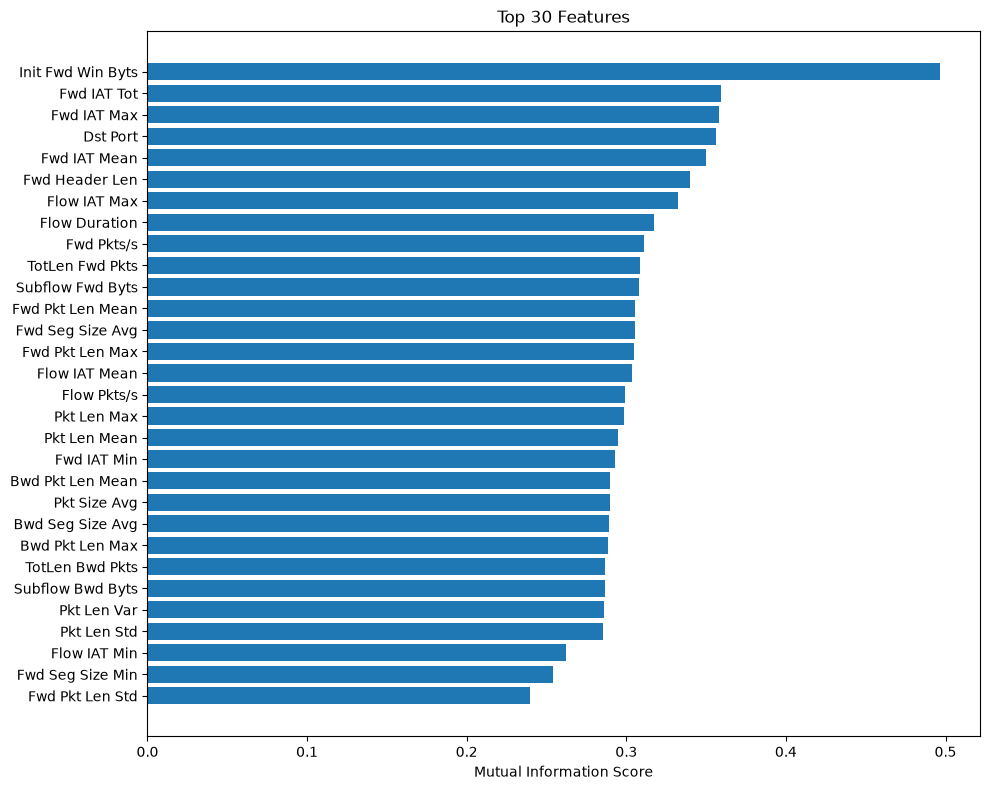

In [33]:
plt.figure(figsize=(10, 8))
top30 = feature_scores.head(30)
plt.barh(top30["Feature"][::-1], top30["MI Score"][::-1])
plt.xlabel("Mutual Information Score")
plt.title("Top 30 Features")
plt.tight_layout()
plt.show()

In [34]:
TOP_K = 30
selected_features = feature_scores.head(TOP_K)["Feature"].tolist()

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

train_selected = X_train_selected.copy(); train_selected["Label"] = y_train.values
test_selected = X_test_selected.copy();   test_selected["Label"] = y_test.values

train_selected.to_parquet(PROCESSED_DATA_PATH / "train_selected.parquet", index=False)
test_selected.to_parquet(PROCESSED_DATA_PATH / "test_selected.parquet", index=False)

import pickle
with open(PROCESSED_DATA_PATH / "selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

print("Selected feature sets saved:", train_selected.shape, test_selected.shape)

Selected feature sets saved: (801992, 31) (200498, 31)


## 5. Augmentation of Minority Classes

Not every minority class gets the same treatment, based on how many real samples it actually has:

- **Very rare classes (< `MIN_SAMPLES_FOR_CTGAN` real rows)** — CTGAN cannot learn a reliable joint
  distribution from a few hundred examples across 30 features. Instead we use **bootstrap
  resampling + small Gaussian jitter**: real rows are resampled with replacement and perturbed
  slightly. This can't invent new attack "shapes" the way CTGAN can, but it also can't hallucinate
  an unrealistic distribution — it stays anchored to what's actually real.
- **Better-populated classes (≥ `MIN_SAMPLES_FOR_CTGAN`)** — CTGAN is used, but the amount of
  synthetic data generated is **capped at `MAX_SYNTHETIC_RATIO`× the real count**, rather than
  blindly generating however many rows are needed to hit `target_count`. Forcing CTGAN to
  fabricate, say, 95% of a class from a few hundred real examples produces synthetic data that
  doesn't resemble the real thing (confirmed empirically — see the sanity-check diagnostics in
  Section 6). Capping the ratio means these classes end up **below** their nominal target, but
  the data that does exist is trustworthy.

Net effect: the final training set is **not** perfectly balanced at a uniform ceiling across every
minority class — but every row in it, real or synthetic, is representative of the real attack
pattern it claims to be.

In [44]:
# pip install ctgan   (run once, outside the notebook, if not already installed)
import json as _json
import numpy as np
import torch
from ctgan import CTGAN
import joblib

USE_CUDA = torch.cuda.is_available()
print("CUDA available:", USE_CUDA)
if USE_CUDA:
    print("GPU:", torch.cuda.get_device_name(0))

# --- Thresholds controlling which classes get CTGAN vs. bootstrap+jitter ---
MIN_SAMPLES_FOR_CTGAN = 1000     # below this, CTGAN can't reliably learn the distribution
MAX_SYNTHETIC_RATIO = 3       # for CTGAN classes, synthetic rows capped at this multiple of real rows

CUDA available: True
GPU: NVIDIA GeForce RTX 2050


In [45]:
def bootstrap_oversample(class_df, class_label, generate_count, noise_scale=0.02, random_state=42):
    """
    Resample real rows with replacement + small Gaussian jitter (proportional to each
    feature's std). Used for classes with too few real samples for CTGAN to learn a
    meaningful distribution from. This can't create new attack "shapes" the way a generative
    model can, but it also can't drift away from the real distribution the way CTGAN did on
    "Brute Force -Web" (220% mean diff) and similar ultra-rare classes.
    """
    rng = np.random.default_rng(random_state)
    X = class_df.drop(columns=["Label"])

    sampled = X.sample(n=generate_count, replace=True, random_state=random_state).reset_index(drop=True)

    numeric_cols = sampled.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        std = X[col].std()
        if std > 0:
            sampled[col] = sampled[col] + rng.normal(0, std * noise_scale, size=len(sampled))

    non_negative_columns = [c for c in numeric_cols if (X[c] >= 0).all()]
    sampled[non_negative_columns] = sampled[non_negative_columns].clip(lower=0)

    sampled["Label"] = class_label
    return sampled


def augment_class(train_df, class_name, target_count, epochs=500, batch_size=500,
                   pac=10, skew_threshold=1.0,
                   min_samples_for_ctgan=None, max_synthetic_ratio=None):
    """
    Bring a class up toward target_count, choosing the safest method based on how much
    real data actually exists:

    - fewer than `min_samples_for_ctgan` real rows -> bootstrap + jitter (Section 5 markdown
      explains why: CTGAN needs enough real data to learn from, or it hallucinates).
    - otherwise -> CTGAN, but synthetic rows are capped at `max_synthetic_ratio` x the real
      count, so a class isn't forced to be 90%+ fabricated just to hit target_count.
    """
    min_samples_for_ctgan = MIN_SAMPLES_FOR_CTGAN if min_samples_for_ctgan is None else min_samples_for_ctgan
    max_synthetic_ratio = MAX_SYNTHETIC_RATIO if max_synthetic_ratio is None else max_synthetic_ratio

    class_label = label_to_id[class_name] if isinstance(class_name, str) else class_name
    safe_name = str(class_name).replace("/", "_").replace(" ", "_")

    class_df = train_df[train_df["Label"] == class_label].copy()
    current_count = len(class_df)

    if current_count == 0:
        print(f"[{class_name}] no real samples found, skipping.")
        return None

    # --- Path A: too few real samples for CTGAN -> bootstrap + jitter, straight to target_count ---
    if current_count < min_samples_for_ctgan:
        generate_count = target_count - current_count
        print(f"[{class_name}] current={current_count} (< {min_samples_for_ctgan}) "
              f"-> using bootstrap+jitter, to_generate={max(generate_count, 0)}")

        if generate_count <= 0:
            print("  -> already at/above target, skipping.")
            return None

        synthetic = bootstrap_oversample(class_df, class_label, generate_count)
        synthetic.to_parquet(CTGAN_SYNTHETIC_PATH / f"{safe_name}.parquet", index=False)
        print("  -> done (bootstrap+jitter).")
        return synthetic

    # --- Path B: enough real samples -> CTGAN, but cap the synthetic:real ratio ---
    effective_target = min(target_count, current_count * (1 + max_synthetic_ratio))
    generate_count = effective_target - current_count

    print(f"[{class_name}] current={current_count}  target={target_count}  "
          f"ratio-capped effective_target={effective_target}  to_generate={generate_count}")

    if generate_count <= 0:
        print("  -> already at/above effective target, skipping.")
        return None

    X = class_df.drop(columns=["Label"])
    discrete_columns = [c for c in ("Dst Port", "Protocol") if c in X.columns]
    continuous_columns = [c for c in X.columns if c not in discrete_columns]

    skewed_columns = [
        c for c in continuous_columns
        if (X[c] >= 0).all() and X[c].skew() > skew_threshold
    ]
    non_negative_columns = [c for c in continuous_columns if (X[c] >= 0).all()]

    X_transformed = X.copy()
    for col in skewed_columns:
        X_transformed[col] = np.log1p(X_transformed[col])

    if batch_size % pac != 0:
        adjusted = max(pac, (batch_size // pac) * pac)
        print(f"  Adjusted batch_size {batch_size} -> {adjusted} (must be divisible by pac={pac})")
        batch_size = adjusted

    ctgan = CTGAN(epochs=epochs, batch_size=batch_size, pac=pac, verbose=True, cuda=True)
    ctgan.fit(X_transformed, discrete_columns=discrete_columns)

    joblib.dump(ctgan, CTGAN_MODELS_PATH / f"{safe_name}_ctgan.pkl")
    with open(CTGAN_MODELS_PATH / f"{safe_name}_log_columns.json", "w") as f:
        _json.dump(skewed_columns, f)

    synthetic = ctgan.sample(generate_count)

    for col in skewed_columns:
        synthetic[col] = np.expm1(synthetic[col])

    synthetic[non_negative_columns] = synthetic[non_negative_columns].clip(lower=0)
    synthetic["Label"] = class_label

    synthetic.to_parquet(CTGAN_SYNTHETIC_PATH / f"{safe_name}.parquet", index=False)
    print("  -> done (CTGAN, ratio-capped).")

    return synthetic

In [37]:
train_selected = pd.read_parquet(PROCESSED_DATA_PATH / "train_selected.parquet")
train_selected["Label"].value_counts().sort_index()

Label
0     680805
1      14293
2        489
3        184
4      33844
5       1384
6      29171
7       2099
8      22017
9        986
10       521
11      1992
12      8197
13        70
14      5940
Name: count, dtype: int64

### Downsample the Majority Class (Benign) — Training Set Only

`Benign` alone makes up roughly 79% of the training set (680,805 of ~858,000 rows) — far more
dominant than any single attack type. This is left completely untouched in `test_selected`
(the test set must stay representative of real-world proportions for evaluation to mean
anything), but for **training**, this level of dominance can bias the model toward always
predicting Benign and drown out the gradient signal from attack classes.

We cap `Benign` at 100,000 rows via random undersampling. The other large classes
(`DDOS attack-HOIC` ~33.8k, `DDoS attacks-LOIC-HTTP` ~29k, `DoS attacks-Hulk` ~22k) are left as-is
— they're an order of magnitude smaller than Benign already, and capping them too wasn't judged
necessary.

In [46]:
BENIGN_CLASS_NAME = "Benign"
BENIGN_CAP = 100_000

benign_id = label_to_id[BENIGN_CLASS_NAME]
benign_mask = train_selected["Label"] == benign_id
current_benign = int(benign_mask.sum())

if current_benign > BENIGN_CAP:
    benign_rows = train_selected[benign_mask].sample(n=BENIGN_CAP, random_state=42)
    other_rows = train_selected[~benign_mask]
    train_selected = pd.concat([other_rows, benign_rows], ignore_index=True)
    print(f"Downsampled {BENIGN_CLASS_NAME}: {current_benign:,} -> {BENIGN_CAP:,}")
else:
    print(f"{BENIGN_CLASS_NAME} count ({current_benign:,}) already <= cap ({BENIGN_CAP:,}), no change made.")

train_selected["Label"].map(id_to_label).value_counts()

Benign count (100,000) already <= cap (100,000), no change made.


Label
Benign                      100000
DDOS attack-HOIC             33844
DDoS attacks-LOIC-HTTP       29171
DoS attacks-Hulk             22017
Bot                          14293
Infilteration                 8197
SSH-Bruteforce                5940
DoS attacks-GoldenEye         2099
FTP-BruteForce                1992
DDOS attack-LOIC-UDP          1384
DoS attacks-SlowHTTPTest       986
DoS attacks-Slowloris          521
Brute Force -Web               489
Brute Force -XSS               184
SQL Injection                   70
Name: count, dtype: int64

**Grouping note:** SQL Injection is excluded entirely (real count = 70, far below any
reasonable threshold for either method) — every real SQL Injection row already present in
`train_selected` still flows into `balanced_train_selected` untouched, so the model still sees
and learns from the real (if few) examples that exist.

For everything else below, `augment_class` automatically picks bootstrap+jitter or ratio-capped
CTGAN per class based on the real counts you found:

| Class | Real Count | Method Used |
|---|---|---|
| Brute Force -XSS | 184 | Bootstrap + jitter |
| Brute Force -Web | 489 | Bootstrap + jitter |
| DoS attacks-Slowloris | 521 | CTGAN, ratio-capped |
| DoS attacks-SlowHTTPTest | 986 | CTGAN, ratio-capped |
| DDOS attack-LOIC-UDP | 1,384 | CTGAN, ratio-capped |
| DoS attacks-GoldenEye | 2,099 | CTGAN, ratio-capped |
| Infilteration | 8,197 | CTGAN, ratio-capped (well under the cap already) |
| Bot | 14,293 | Skipped — already above target |

> None of these classes will necessarily reach exactly 10,000 rows anymore — that's expected and
> intentional. Check the printed `effective_target` for each class after running the cell below.

In [47]:
TARGET_COUNTS = {
    "Bot": 10_000,
    "Infilteration": 10_000,
    "DoS attacks-Slowloris": 10_000,
    "DoS attacks-SlowHTTPTest": 10_000,
    "DoS attacks-GoldenEye": 10_000,
    "DDOS attack-LOIC-UDP": 10_000,
    "Brute Force -Web": 10_000,
    "Brute Force -XSS": 10_000,
    "SSH-Bruteforce":10_000,
    "FTP-BruteForce":10_000,
}

for class_name, target in TARGET_COUNTS.items():
    augment_class(train_selected, class_name, target)

[Bot] current=14293  target=10000  ratio-capped effective_target=10000  to_generate=-4293
  -> already at/above effective target, skipping.
[Infilteration] current=8197  target=10000  ratio-capped effective_target=10000  to_generate=1803


Gen. (-01.12) | Discrim. (-00.10): 100%|██████████| 500/500 [30:50<00:00,  3.70s/it]    


  -> done (CTGAN, ratio-capped).
[DoS attacks-Slowloris] current=521 (< 1000) -> using bootstrap+jitter, to_generate=9479
  -> done (bootstrap+jitter).
[DoS attacks-SlowHTTPTest] current=986 (< 1000) -> using bootstrap+jitter, to_generate=9014
  -> done (bootstrap+jitter).
[DoS attacks-GoldenEye] current=2099  target=10000  ratio-capped effective_target=8396  to_generate=6297


Gen. (-01.34) | Discrim. (-00.91): 100%|██████████| 500/500 [04:35<00:00,  1.82it/s]


  -> done (CTGAN, ratio-capped).
[DDOS attack-LOIC-UDP] current=1384  target=10000  ratio-capped effective_target=5536  to_generate=4152


...

  -> done (CTGAN, ratio-capped).
[Brute Force -Web] current=489 (< 1000) -> using bootstrap+jitter, to_generate=9511
  -> done (bootstrap+jitter).
[Brute Force -XSS] current=184 (< 1000) -> using bootstrap+jitter, to_generate=9816
  -> done (bootstrap+jitter).
[SSH-Bruteforce] current=5940  target=10000  ratio-capped effective_target=10000  to_generate=4060


Gen. (-02.33) | Discrim. (+00.85): 100%|██████████| 500/500 [11:12<00:00,  1.35s/it]


  -> done (CTGAN, ratio-capped).
[FTP-BruteForce] current=1992  target=10000  ratio-capped effective_target=7968  to_generate=5976


Gen. (+02.27) | Discrim. (-00.29): 100%|██████████| 500/500 [14:37<00:00,  1.76s/it]    


  -> done (CTGAN, ratio-capped).


## 6. Sanity Check: Real vs. Synthetic (one class)

In [48]:
# Map sanitized filenames (spaces/slashes replaced with "_") back to the original class names,
# since augment_class() sanitizes class_name when writing the synthetic file.
safe_name_to_class = {
    str(cls).replace("/", "_").replace(" ", "_"): cls
    for cls in label_to_id.keys()
}

synthetic_class_files = {f.stem: f for f in CTGAN_SYNTHETIC_PATH.glob("*.parquet")}

if not synthetic_class_files:
    print("No synthetic files found -- every class may already be at/above its target.")
else:
    summary_rows = []

    for safe_name, file_path in synthetic_class_files.items():
        check_class = safe_name_to_class.get(safe_name, safe_name)

        synthetic_check = pd.read_parquet(file_path)
        real_subset = train_selected[
            train_selected["Label"] == label_to_id[check_class]
        ].drop(columns=["Label"])
        synthetic_subset = synthetic_check.drop(columns=["Label"])

        comparison_diag = pd.DataFrame({
            "Real Mean": real_subset.mean(),
            "Synthetic Mean": synthetic_subset.mean(),
            "Real Std": real_subset.std(),
            "Synthetic Std": synthetic_subset.std(),
        })
        comparison_diag["Mean Diff %"] = (
            (comparison_diag["Real Mean"] - comparison_diag["Synthetic Mean"]).abs()
            / (comparison_diag["Real Mean"].abs() + 1e-8) * 100
        )
        comparison_diag["Std Diff %"] = (
            (comparison_diag["Real Std"] - comparison_diag["Synthetic Std"]).abs()
            / (comparison_diag["Real Std"].abs() + 1e-8) * 100
        )
        comparison_diag = comparison_diag.round(2)
        comparison_diag.to_csv(RESULTS_PATH / f"{check_class}_ctgan_comparison.csv")

        summary_rows.append({
            "Class": check_class,
            "Real Count": len(real_subset),
            "Synthetic Count": len(synthetic_subset),
            "Avg Mean Diff %": comparison_diag["Mean Diff %"].mean(),
            "Avg Std Diff %": comparison_diag["Std Diff %"].mean(),
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .round(2)
        .sort_values("Avg Mean Diff %", ascending=False)
        .reset_index(drop=True)
    )
    summary_df.to_csv(RESULTS_PATH / "ctgan_all_classes_summary.csv", index=False)

    print(summary_df)

                      Class  Real Count  Synthetic Count  Avg Mean Diff %  \
0            FTP-BruteForce        1992             5976       1050007.89   
1      DDOS attack-LOIC-UDP        1384             4152        980175.37   
2             Infilteration        8197             1803            96.67   
3     DoS attacks-GoldenEye        2099             6297            22.28   
4            SSH-Bruteforce        5940             4060             4.56   
5     DoS attacks-Slowloris         521             9479             2.09   
6          Brute Force -XSS         184             9816             1.54   
7          Brute Force -Web         489             9511             1.47   
8  DoS attacks-SlowHTTPTest         986             9014             0.34   

   Avg Std Diff %  
0      1180172.75  
1      2378215.30  
2           72.71  
3           23.37  
4            7.77  
5            2.50  
6            0.67  
7            0.98  
8            0.18  


In [49]:
safe_name_to_class = {
    str(cls).replace("/", "_").replace(" ", "_"): cls
    for cls in label_to_id.keys()
}

synthetic_class_files = {f.stem: f for f in CTGAN_SYNTHETIC_PATH.glob("*.parquet")}

NEAR_ZERO_THRESHOLD = 1.0  # features with |real mean| below this are excluded from the headline average

if not synthetic_class_files:
    print("No synthetic files found -- every class may already be at/above its target.")
else:
    summary_rows = []

    for safe_name, file_path in synthetic_class_files.items():
        check_class = safe_name_to_class.get(safe_name, safe_name)

        synthetic_check = pd.read_parquet(file_path)
        real_subset = train_selected[
            train_selected["Label"] == label_to_id[check_class]
        ].drop(columns=["Label"])
        synthetic_subset = synthetic_check.drop(columns=["Label"])

        comparison_diag = pd.DataFrame({
            "Real Mean": real_subset.mean(),
            "Synthetic Mean": synthetic_subset.mean(),
            "Real Std": real_subset.std(),
            "Synthetic Std": synthetic_subset.std(),
        })
        comparison_diag["Mean Diff %"] = (
            (comparison_diag["Real Mean"] - comparison_diag["Synthetic Mean"]).abs()
            / (comparison_diag["Real Mean"].abs() + 1e-8) * 100
        )
        comparison_diag["Std Diff %"] = (
            (comparison_diag["Real Std"] - comparison_diag["Synthetic Std"]).abs()
            / (comparison_diag["Real Std"].abs() + 1e-8) * 100
        )
        comparison_diag = comparison_diag.round(2)
        comparison_diag.to_csv(RESULTS_PATH / f"{check_class}_ctgan_comparison.csv")

        substantive_mean = comparison_diag[comparison_diag["Real Mean"].abs() >= NEAR_ZERO_THRESHOLD]
        substantive_std = comparison_diag[comparison_diag["Real Std"].abs() >= NEAR_ZERO_THRESHOLD]

        summary_rows.append({
            "Class": check_class,
            "Real Count": len(real_subset),
            "Synthetic Count": len(synthetic_subset),
            "Substantive Mean-Diff Features": len(substantive_mean),
            "Substantive Avg Mean Diff %": substantive_mean["Mean Diff %"].mean() if len(substantive_mean) else float("nan"),
            "Substantive Std-Diff Features": len(substantive_std),
            "Substantive Avg Std Diff %": substantive_std["Std Diff %"].mean() if len(substantive_std) else float("nan"),
            "All-Features Avg Mean Diff %": comparison_diag["Mean Diff %"].mean(),
        })
    summary_df = (
        pd.DataFrame(summary_rows)
        .round(2)
        .sort_values("Substantive Avg Mean Diff %", ascending=False)
        .reset_index(drop=True)
    )
    summary_df.to_csv(RESULTS_PATH / "ctgan_all_classes_summary.csv", index=False)

    print(summary_df)


                      Class  Real Count  Synthetic Count  \
0             Infilteration        8197             1803   
1     DoS attacks-GoldenEye        2099             6297   
2            SSH-Bruteforce        5940             4060   
3            FTP-BruteForce        1992             5976   
4      DDOS attack-LOIC-UDP        1384             4152   
5     DoS attacks-Slowloris         521             9479   
6          Brute Force -XSS         184             9816   
7          Brute Force -Web         489             9511   
8  DoS attacks-SlowHTTPTest         986             9014   

   Substantive Mean-Diff Features  Substantive Avg Mean Diff %  \
0                              30                        96.67   
1                              30                        22.28   
2                              30                         4.56   
3                              10                         3.39   
4                              20                         2.77   
5  

In [50]:
# Separate near-zero-mean features (can inflate % diffs) from substantive ones
NEAR_ZERO_THRESHOLD = 1.0

near_zero = comparison_diag[comparison_diag["Real Mean"].abs() < NEAR_ZERO_THRESHOLD]
substantive = comparison_diag[comparison_diag["Real Mean"].abs() >= NEAR_ZERO_THRESHOLD]

print(f"Near-zero features   ({len(near_zero)}): avg Mean Diff % = {near_zero['Mean Diff %'].mean():.2f}")
print(f"Substantive features ({len(substantive)}): avg Mean Diff % = {substantive['Mean Diff %'].mean():.2f}")

substantive.sort_values("Mean Diff %", ascending=False)

Near-zero features   (0): avg Mean Diff % = nan
Substantive features (30): avg Mean Diff % = 4.56


,Real Mean,Synthetic Mean,Real Std,Synthetic Std,Mean Diff %,Std Diff %
Flow IAT Min,17.31,4.80,668.75,2.62,72.30,99.61
Fwd IAT Min,200.23,158.41,674.82,89.53,20.89,86.73
Flow Pkts/s,62252.28,54816.53,133484.10,115511.99,11.94,13.46
Fwd IAT Max,83637.91,92651.15,51062.32,52955.66,10.78,3.71
Fwd Pkts/s,31181.44,29856.58,66810.61,63076.46,4.25,5.59
Fwd IAT Mean,13649.32,14101.06,6986.44,7056.16,3.31,1.00
Flow IAT Mean,6849.24,6987.43,3538.15,3497.44,2.02,1.15
Fwd IAT Tot,291815.85,296651.86,149215.55,148120.61,1.66,0.73
Fwd Pkt Len Mean,69.08,68.06,34.81,34.72,1.47,0.27
Flow IAT Max,80871.55,81692.43,50483.01,46148.12,1.02,8.59


## 7. Merge Synthetic Data → Final Balanced Training Set

In [51]:
synthetic_files = sorted(CTGAN_SYNTHETIC_PATH.glob("*.parquet"))
synthetic_df = pd.concat([pd.read_parquet(f) for f in synthetic_files], ignore_index=True)

print("Synthetic rows:", synthetic_df.shape)
synthetic_df["Label"].map(id_to_label).value_counts()

Synthetic rows: (60108, 31)


Label
Brute Force -XSS            9816
Brute Force -Web            9511
DoS attacks-Slowloris       9479
DoS attacks-SlowHTTPTest    9014
DoS attacks-GoldenEye       6297
FTP-BruteForce              5976
DDOS attack-LOIC-UDP        4152
SSH-Bruteforce              4060
Infilteration               1803
Name: count, dtype: int64

In [52]:
balanced_train = pd.concat([train_selected, synthetic_df], ignore_index=True)

balanced_train.to_parquet(
    PROCESSED_DATA_PATH / "balanced_train_selected.parquet", index=False
)

print("Balanced training set:", balanced_train.shape)
balanced_train["Label"].map(id_to_label).value_counts()

Balanced training set: (281295, 31)


Label
Benign                      100000
DDOS attack-HOIC             33844
DDoS attacks-LOIC-HTTP       29171
DoS attacks-Hulk             22017
Bot                          14293
Infilteration                10000
SSH-Bruteforce               10000
DoS attacks-SlowHTTPTest     10000
Brute Force -XSS             10000
Brute Force -Web             10000
DoS attacks-Slowloris        10000
DoS attacks-GoldenEye         8396
FTP-BruteForce                7968
DDOS attack-LOIC-UDP          5536
SQL Injection                   70
Name: count, dtype: int64

In [53]:
import pandas as pd
from pathlib import Path

PROJECT_PATH = Path(r"M:\IDS\c_filesnew")
FINAL_CLEANED_PATH = PROJECT_PATH / "Final_Cleaned"
PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"

files_to_check = {
        "train_selected.parquet": PROCESSED_DATA_PATH / "train_selected.parquet",
        "balanced_train_selected.parquet": PROCESSED_DATA_PATH / "balanced_train_selected.parquet",
}

for name, path in files_to_check.items():
    if not path.exists():
        print(f"{name}: file not found at {path}")
        continue

    df = pd.read_parquet(path)
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("'rn' present:", "rn" in df.columns)
    print("Columns:", list(df.columns))
    print()


--- train_selected.parquet ---
Shape: (801992, 31)
'rn' present: False
Columns: ['Init Fwd Win Byts', 'Fwd IAT Tot', 'Fwd IAT Max', 'Dst Port', 'Fwd IAT Mean', 'Fwd Header Len', 'Flow IAT Max', 'Flow Duration', 'Fwd Pkts/s', 'TotLen Fwd Pkts', 'Subflow Fwd Byts', 'Fwd Pkt Len Mean', 'Fwd Seg Size Avg', 'Fwd Pkt Len Max', 'Flow IAT Mean', 'Flow Pkts/s', 'Pkt Len Max', 'Pkt Len Mean', 'Fwd IAT Min', 'Bwd Pkt Len Mean', 'Pkt Size Avg', 'Bwd Seg Size Avg', 'Bwd Pkt Len Max', 'TotLen Bwd Pkts', 'Subflow Bwd Byts', 'Pkt Len Var', 'Pkt Len Std', 'Flow IAT Min', 'Fwd Seg Size Min', 'Fwd Pkt Len Std', 'Label']

--- balanced_train_selected.parquet ---
Shape: (281295, 31)
'rn' present: False
Columns: ['Init Fwd Win Byts', 'Fwd IAT Tot', 'Fwd IAT Max', 'Dst Port', 'Fwd IAT Mean', 'Fwd Header Len', 'Flow IAT Max', 'Flow Duration', 'Fwd Pkts/s', 'TotLen Fwd Pkts', 'Subflow Fwd Byts', 'Fwd Pkt Len Mean', 'Fwd Seg Size Avg', 'Fwd Pkt Len Max', 'Flow IAT Mean', 'Flow Pkts/s', 'Pkt Len Max', 'Pkt Len Me

---
**Outputs produced by this notebook (under `Processed_Data/`):**
- `train.parquet` / `test.parquet` — full-feature split
- `train_selected.parquet` / `test_selected.parquet` — top-30-feature split
- `label_mapping.csv`, `selected_features.pkl`
- `balanced_train_selected.parquet` — final CTGAN-augmented, class-balanced training set

This `balanced_train_selected.parquet` (together with `test_selected.parquet` for evaluation)
is what should be fed into model training.